In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

ruta = "/content/drive/MyDrive/dataset_original"

print(os.listdir(ruta))

['daisy', 'dandelion', 'tulip', 'sunflower', 'rose']


In [4]:
import cv2
import os

dataset_original = "/content/drive/MyDrive/dataset_original"

dataset_procesado = "/content/drive/MyDrive/flowers_clahe"

os.makedirs(dataset_procesado, exist_ok=True)

for clase in os.listdir(dataset_original):

    ruta_clase_original = os.path.join(dataset_original, clase)

    ruta_clase_nueva = os.path.join(dataset_procesado, clase)

    os.makedirs(ruta_clase_nueva, exist_ok=True)

    for archivo in os.listdir(ruta_clase_original):

        ruta_imagen = os.path.join(ruta_clase_original, archivo)

        imagen = cv2.imread(ruta_imagen)

        if imagen is None:
            continue

        imagen = cv2.resize(imagen, (150,150))

        lab = cv2.cvtColor(imagen, cv2.COLOR_BGR2LAB)

        canal_l, canal_a, canal_b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        )

        canal_l = clahe.apply(canal_l)

        lab = cv2.merge((canal_l, canal_a, canal_b))

        imagen_final = cv2.cvtColor(
            lab,
            cv2.COLOR_LAB2BGR
        )

        ruta_guardado = os.path.join(
            ruta_clase_nueva,
            archivo
        )

        cv2.imwrite(
            ruta_guardado,
            imagen_final
        )

print("Proceso terminado")

Proceso terminado


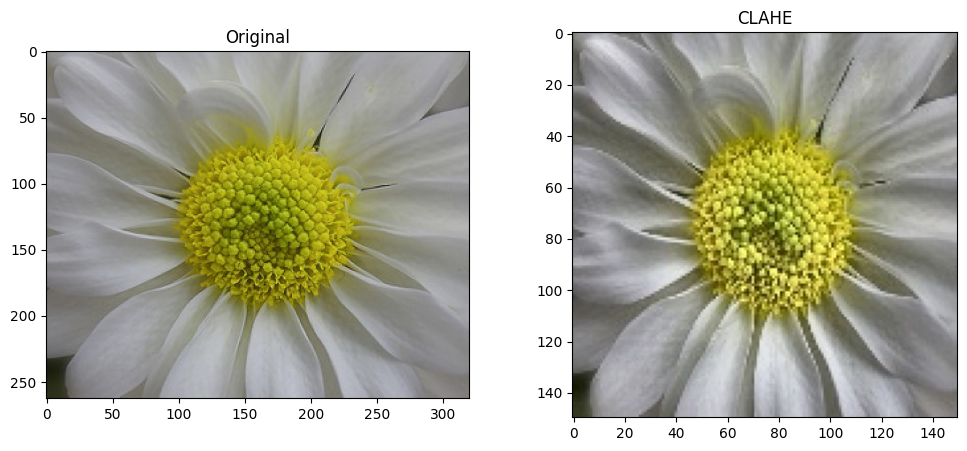

In [7]:
import matplotlib.pyplot as plt
import cv2

original = cv2.imread(
"/content/drive/MyDrive/dataset_original/daisy/100080576_f52e8ee070_n.jpg"
)

procesada = cv2.imread(
"/content/drive/MyDrive/flowers_clahe/daisy/100080576_f52e8ee070_n.jpg"
)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

procesada = cv2.cvtColor(
    procesada,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(procesada)
plt.title("CLAHE")

plt.show()